# 01 – Yelp Data Exploration

Quick overview of the Yelp dataset via DuckDB.

**Pre-requisites** – Parquet files must be available at path below.

## Setup

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PARQUET_DIR = Path("../../../Yelp-JSON/yelp_parquet")
business_files = sorted(PARQUET_DIR.glob("business/state=*/*.parquet"))
review_files = sorted(PARQUET_DIR.glob("review/year=*/*.parquet"))

con = duckdb.connect(":memory:")
print(f"DuckDB connected")
print(f"Found {len(business_files)} business Parquet files")
print(f"Found {len(review_files)} review Parquet files")

DuckDB connected
Found 27 business Parquet files
Found 18 review Parquet files


## Data Structure Overview

In [22]:
# Business table preview
print("=" * 80)
print("BUSINESS TABLE SAMPLE")
print("=" * 80)
business_flat = str(PARQUET_DIR / "business" / "state=*" / "*.parquet")
review_flat = str(PARQUET_DIR / "review" / "year=*" / "*.parquet")

sample_biz = con.execute(f"""
    SELECT * FROM read_parquet('{business_flat}')
    LIMIT 5
""").fetch_df()

print("\nFirst 5 businesses:")
print(sample_biz.to_string(index=False))

# Review table preview
print("\n" + "=" * 80)
print("REVIEW TABLE SAMPLE")
print("=" * 80)
sample_rev = con.execute(f"""
    SELECT * FROM read_parquet('{review_flat}')
    LIMIT 5
""").fetch_df()

print("\nFirst 5 reviews:")
print(sample_rev.to_string(index=False))

print("\n" + "=" * 80)

BUSINESS TABLE SAMPLE

First 5 businesses:
           business_id                             name                  address          city postal_code  latitude   longitude  stars  review_count  is_open                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

## Business Overview

In [2]:
business_flat = str(PARQUET_DIR / "business" / "state=*" / "*.parquet")
biz_stats = con.execute(f"""
    SELECT 
        COUNT(*) as total_businesses,
        COUNT(DISTINCT state) as num_states,
        ROUND(AVG(review_count), 2) as avg_reviews,
        MIN(review_count) as min_reviews,
        MAX(review_count) as max_reviews
    FROM read_parquet('{business_flat}')
""").fetch_df()

print("Business Statistics:")
print(biz_stats)

Business Statistics:
   total_businesses  num_states  avg_reviews  min_reviews  max_reviews
0            150346          27        44.87            5         7568


## City Breakdown

In [3]:
city_stats = con.execute(f"""
    SELECT 
        city, state,
        COUNT(*) as n_business,
        ROUND(AVG(stars), 2) as avg_stars
    FROM read_parquet('{business_flat}')
    GROUP BY city, state
    ORDER BY n_business DESC
    LIMIT 15
""").fetch_df()

print(city_stats)

                city state  n_business  avg_stars
0       Philadelphia    PA       14567       3.62
1             Tucson    AZ        9249       3.59
2              Tampa    FL        9048       3.58
3       Indianapolis    IN        7540       3.58
4          Nashville    TN        6968       3.64
5        New Orleans    LA        6208       3.82
6               Reno    NV        5932       3.76
7           Edmonton    AB        5054       3.44
8        Saint Louis    MO        4827       3.59
9      Santa Barbara    CA        3829       4.05
10             Boise    ID        2937       3.71
11        Clearwater    FL        2221       3.60
12  Saint Petersburg    FL        1663       3.71
13          Metairie    LA        1643       3.49
14            Sparks    NV        1623       3.65


## Review Star Distribution

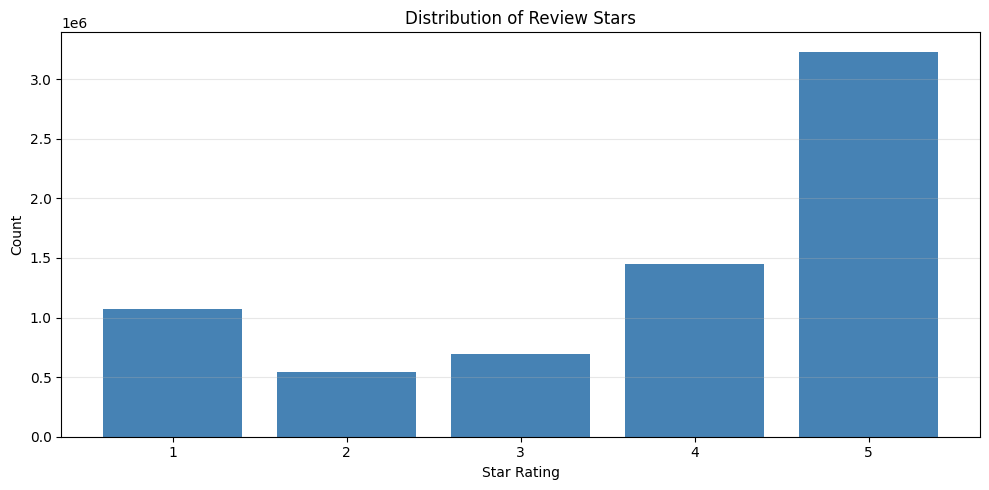


Star distribution:
   stars    count
0      1  1069561
1      2   544240
2      3   691934
3      4  1452918
4      5  3231627


In [4]:
review_flat = str(PARQUET_DIR / "review" / "year=*" / "*.parquet")
star_dist = con.execute(f"""
    SELECT 
        CAST(stars AS INTEGER) as stars,
        COUNT(*) as count
    FROM read_parquet('{review_flat}')
    GROUP BY CAST(stars AS INTEGER)
    ORDER BY stars
""").fetch_df()

plt.figure(figsize=(10, 5))
plt.bar(star_dist['stars'], star_dist['count'], color='steelblue')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.title('Distribution of Review Stars')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nStar distribution:")
print(star_dist)

## Reviews Over Time

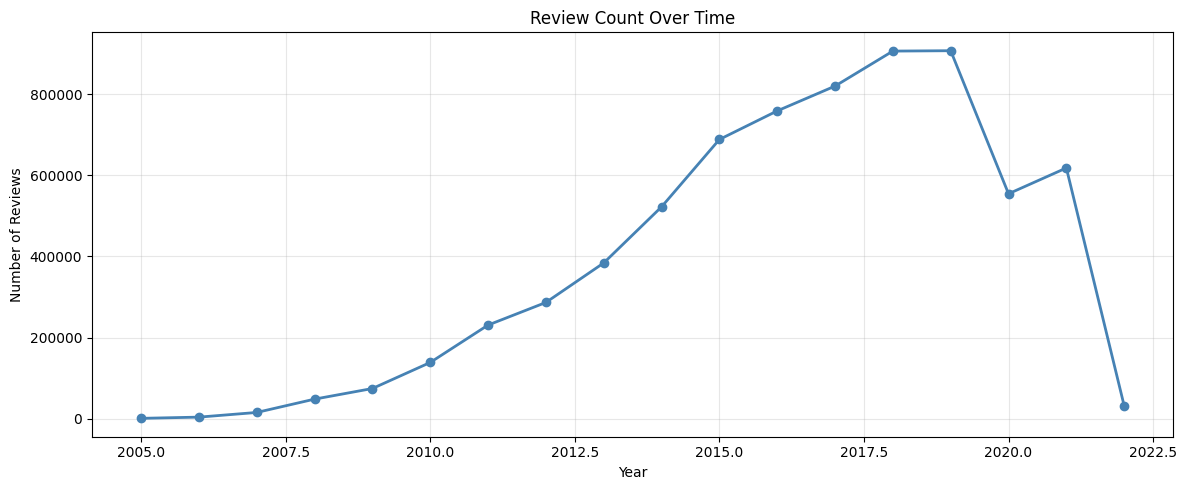


Reviews by year:
    year   count
0   2005     854
1   2006    3853
2   2007   15363
3   2008   48226
4   2009   74387
5   2010  138587
6   2011  230813
7   2012  286570
8   2013  383950
9   2014  522275
10  2015  688415
11  2016  758882
12  2017  820048
13  2018  906362
14  2019  907284
15  2020  554557
16  2021  618189
17  2022   31665


In [5]:
yearly_stats = con.execute(f"""
    SELECT 
        YEAR(date) as year,
        COUNT(*) as count
    FROM read_parquet('{review_flat}')
    GROUP BY YEAR(date)
    ORDER BY year
""").fetch_df()

plt.figure(figsize=(12, 5))
plt.plot(yearly_stats['year'], yearly_stats['count'], linewidth=2, marker='o', color='steelblue')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Review Count Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nReviews by year:")
print(yearly_stats)

## User-Item Sparsity (stars >= 4.0)

In [6]:
pos = con.execute(f"""
    SELECT 
        COUNT(DISTINCT user_id) as n_u,
        COUNT(DISTINCT business_id) as n_i,
        COUNT(*) as n_int
    FROM read_parquet('{review_flat}')
    WHERE stars >= 4.0
""").fetch_df()

n_u, n_i, n_int = pos['n_u'].iloc[0], pos['n_i'].iloc[0], pos['n_int'].iloc[0]
max_possible = n_u * n_i
density = (n_int / max_possible) * 100 if max_possible > 0 else 0

print(f"Implicit feedback matrix (stars >= 4.0):")
print(f"  Users: {n_u:,}")
print(f"  Items: {n_i:,}")
print(f"  Interactions: {n_int:,}")
print(f"  Density: {density:.4f}%")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Implicit feedback matrix (stars >= 4.0):
  Users: 1,464,850
  Items: 147,491
  Interactions: 4,684,545
  Density: 0.0022%


## User Activity Histogram

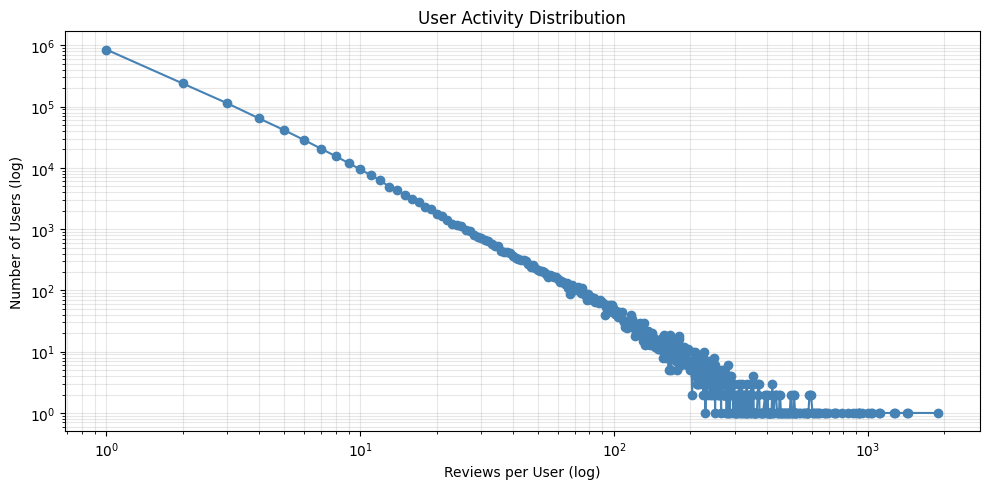


Top reviewers:
   cnt  num_users
0    1     855929
1    2     238623
2    3     113166
3    4      64226
4    5      41640
5    6      28694
6    7      20656
7    8      15556
8    9      12012
9   10       9465


In [7]:
user_counts = con.execute(f"""
    WITH user_acts AS (
        SELECT user_id, COUNT(*) as cnt
        FROM read_parquet('{review_flat}')
        WHERE stars >= 4.0
        GROUP BY user_id
    )
    SELECT cnt, COUNT(*) as num_users
    FROM user_acts
    GROUP BY cnt
    ORDER BY cnt ASC
""").fetch_df()

plt.figure(figsize=(10, 5))
plt.loglog(user_counts['cnt'], user_counts['num_users'], 'o-', color='steelblue')
plt.xlabel('Reviews per User (log)')
plt.ylabel('Number of Users (log)')
plt.title('User Activity Distribution')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("\nTop reviewers:")
print(user_counts.head(10))

In [8]:
# Top business categories
categories = con.execute(f"""
    SELECT 
        categories,
        COUNT(*) as count,
        ROUND(AVG(stars), 2) as avg_stars,
        ROUND(AVG(review_count), 0) as avg_reviews
    FROM read_parquet('{business_flat}')
    WHERE categories IS NOT NULL
    GROUP BY categories
    ORDER BY count DESC
    LIMIT 20
""").fetch_df()

print("Top 20 Business Categories:")
print(categories)

Top 20 Business Categories:
                         categories  count  avg_stars  avg_reviews
0        Beauty & Spas, Nail Salons   1012       3.22         27.0
1                Restaurants, Pizza    935       3.20         35.0
2        Nail Salons, Beauty & Spas    934       3.18         25.0
3                Pizza, Restaurants    823       3.23         35.0
4              Restaurants, Mexican    728       3.63         73.0
5              Restaurants, Chinese    708       3.32         34.0
6              Mexican, Restaurants    672       3.63         79.0
7              Chinese, Restaurants    651       3.29         34.0
8                Food, Coffee & Tea    508       3.48         34.0
9        Beauty & Spas, Hair Salons    493       3.92         18.0
10       Hair Salons, Beauty & Spas    480       3.83         18.0
11               Coffee & Tea, Food    473       3.52         36.0
12          Automotive, Auto Repair    361       4.19         12.0
13          Auto Repair, Automotiv

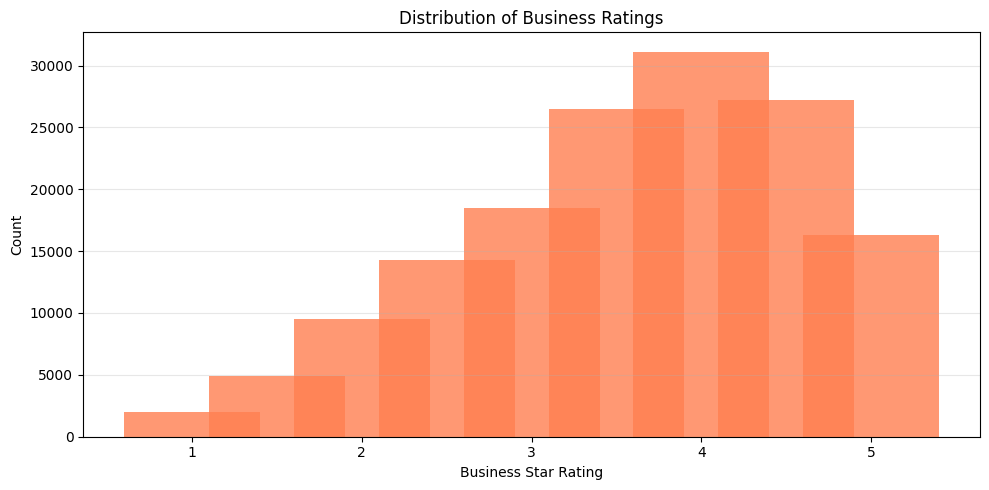

Business rating distribution:
   rating  count
0     1.0   1986
1     1.5   4932
2     2.0   9527
3     2.5  14316
4     3.0  18453
5     3.5  26519
6     4.0  31125
7     4.5  27181
8     5.0  16307


In [9]:
# Distribution of business stars
biz_stars = con.execute(f"""
    SELECT 
        ROUND(stars, 1) as rating,
        COUNT(*) as count
    FROM read_parquet('{business_flat}')
    GROUP BY ROUND(stars, 1)
    ORDER BY rating
""").fetch_df()

plt.figure(figsize=(10, 5))
plt.bar(biz_stars['rating'], biz_stars['count'], color='coral', alpha=0.8)
plt.xlabel('Business Star Rating')
plt.ylabel('Count')
plt.title('Distribution of Business Ratings')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Business rating distribution:")
print(biz_stars)

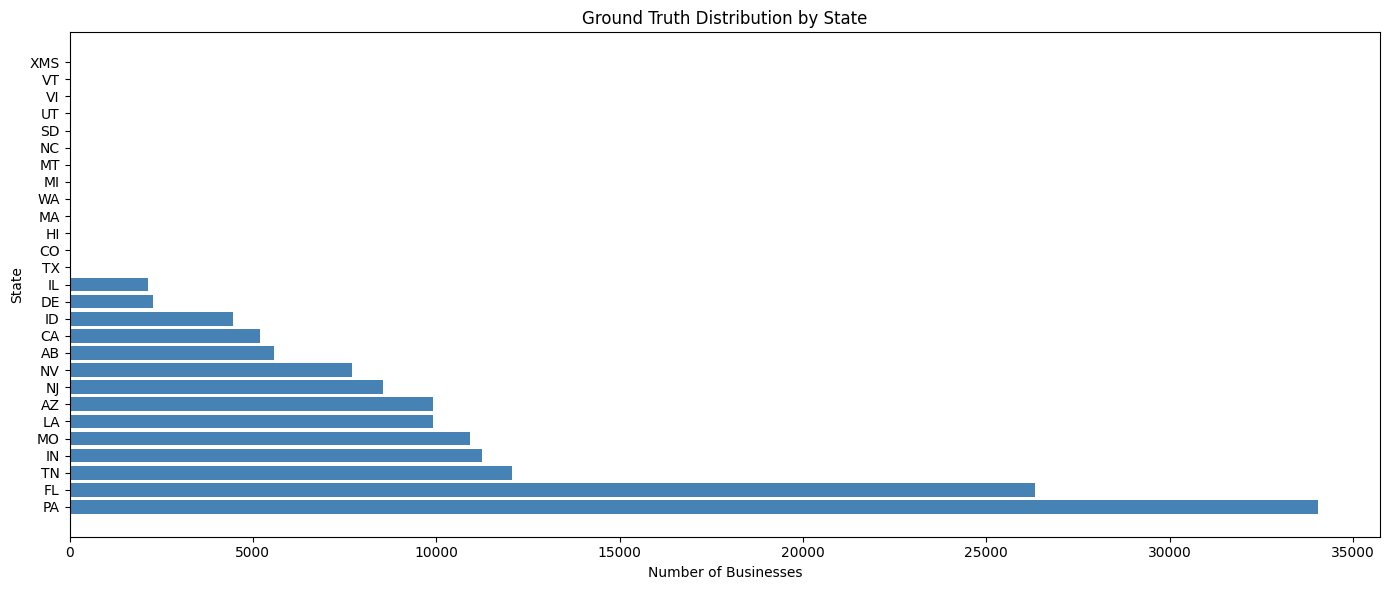

Top 10 states by business count:
  state  n_businesses  avg_rating
0    PA         34039        3.57
1    FL         26330        3.61
2    TN         12056        3.57
3    IN         11247        3.59
4    MO         10913        3.55
5    LA          9924        3.68
6    AZ          9912        3.59
7    NJ          8536        3.46
8    NV          7715        3.74
9    AB          5573        3.45


In [10]:
# State-level distribution
state_dist = con.execute(f"""
    SELECT 
        state,
        COUNT(*) as n_businesses,
        ROUND(AVG(stars), 2) as avg_rating
    FROM read_parquet('{business_flat}')
    GROUP BY state
    ORDER BY n_businesses DESC
""").fetch_df()

plt.figure(figsize=(14, 6))
plt.barh(state_dist['state'], state_dist['n_businesses'], color='steelblue')
plt.xlabel('Number of Businesses')
plt.ylabel('State')
plt.title('Ground Truth Distribution by State')
plt.tight_layout()
plt.show()

print("Top 10 states by business count:")
print(state_dist.head(10))

## Pennsylvania Business Analysis

PENNSYLVANIA BUSINESS OVERVIEW
   total_businesses  avg_rating  min_rating  max_rating  avg_reviews  \
0             34039        3.57         1.0         5.0         45.3   

   min_reviews  max_reviews  
0            5         5721  

Top 15 Cities in PA:
               city  n_businesses  avg_rating  avg_reviews
0      Philadelphia         14567        3.62         64.3
1      West Chester           838        3.60         29.0
2   King of Prussia           560        3.31         44.1
3        Doylestown           539        3.73         28.0
4          Bensalem           454        3.25         28.8
5        Norristown           448        3.47         24.9
6             Exton           419        3.28         30.5
7          Lansdale           378        3.57         29.1
8           Ardmore           376        3.69         41.1
9             Wayne           375        3.64         39.1
10            Media           371        3.68         37.8
11     Phoenixville           365 

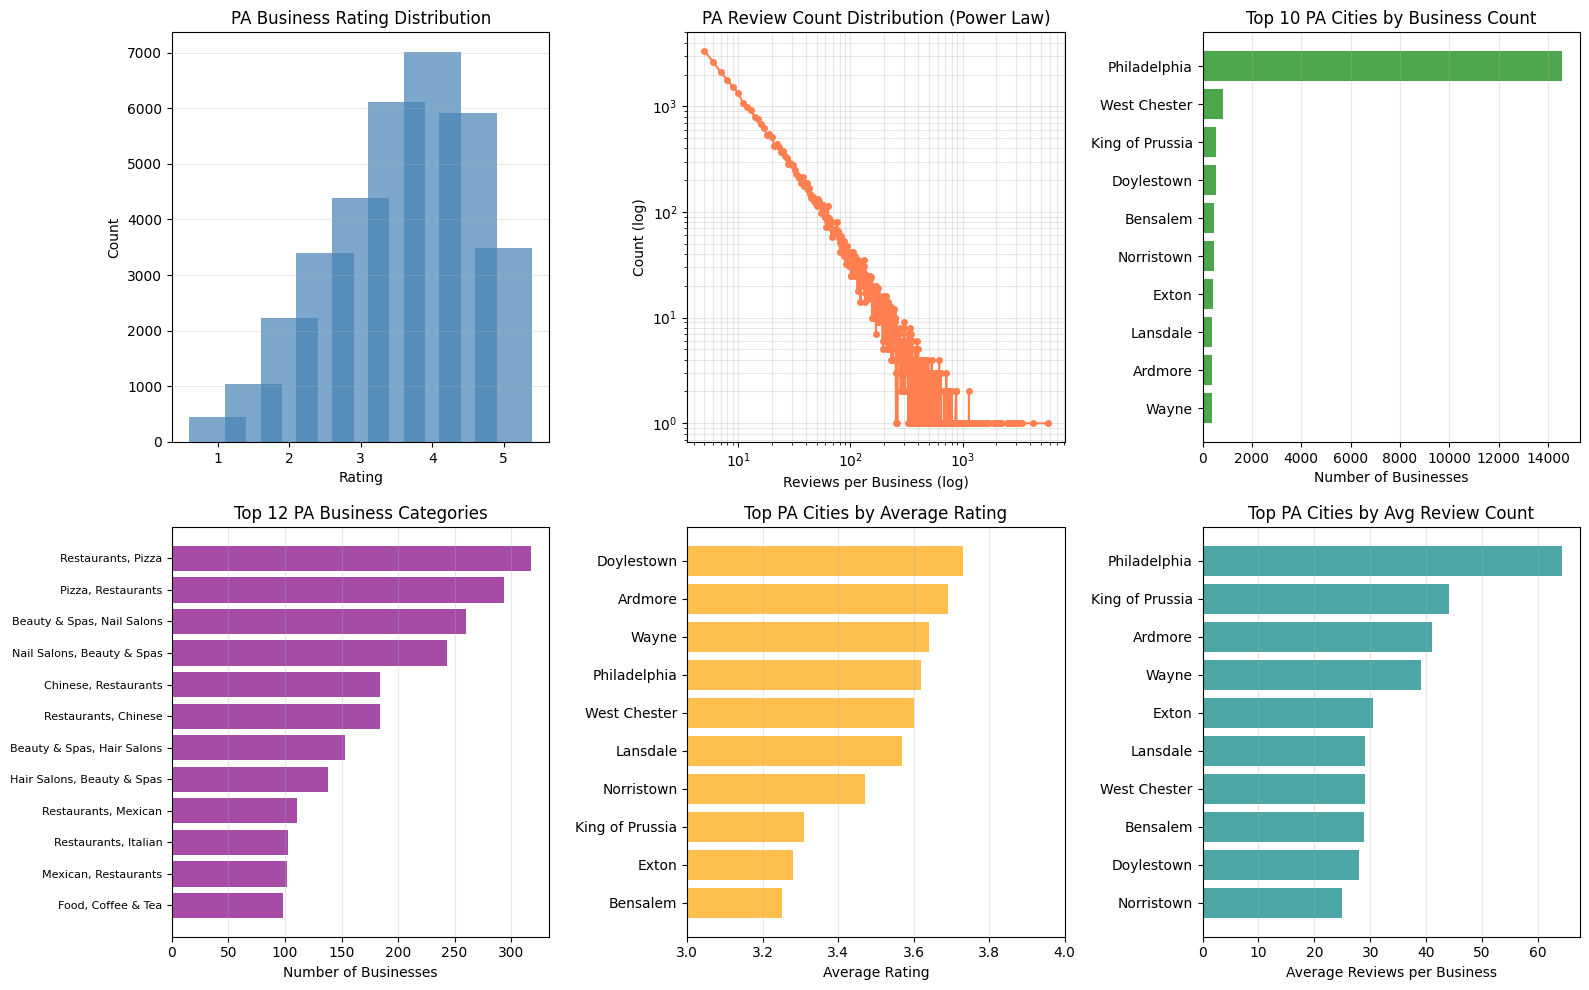


Key Insights:
  • PA has 34,039 registered businesses
  • Average rating: 3.57
  • Average reviews per business: 45.3
  • Review count range: 5 to 5721
  • Most common city: Philadelphia (14567 businesses)
  • Most diverse category: Restaurants, Pizza


In [18]:
# Analyze PA businesses
pa_stats = con.execute(f"""
    SELECT 
        COUNT(*) as total_businesses,
        ROUND(AVG(stars), 2) as avg_rating,
        MIN(stars) as min_rating,
        MAX(stars) as max_rating,
        ROUND(AVG(review_count), 1) as avg_reviews,
        MIN(review_count) as min_reviews,
        MAX(review_count) as max_reviews
    FROM read_parquet('{business_flat}')
    WHERE state = 'PA'
""").fetch_df()

print("=" * 80)
print("PENNSYLVANIA BUSINESS OVERVIEW")
print("=" * 80)
print(pa_stats)

# Top cities in PA
pa_cities = con.execute(f"""
    SELECT 
        city,
        COUNT(*) as n_businesses,
        ROUND(AVG(stars), 2) as avg_rating,
        ROUND(AVG(review_count), 1) as avg_reviews
    FROM read_parquet('{business_flat}')
    WHERE state = 'PA'
    GROUP BY city
    ORDER BY n_businesses DESC
    LIMIT 15
""").fetch_df()

print("\nTop 15 Cities in PA:")
print(pa_cities)

# Category distribution in PA
pa_categories = con.execute(f"""
    SELECT 
        categories,
        COUNT(*) as count,
        ROUND(AVG(stars), 2) as avg_rating
    FROM read_parquet('{business_flat}')
    WHERE state = 'PA' AND categories IS NOT NULL
    GROUP BY categories
    ORDER BY count DESC
    LIMIT 20
""").fetch_df()

print("\nTop 20 Business Category Combinations in PA:")
print(pa_categories)

# Rating distribution in PA
pa_rating_dist = con.execute(f"""
    SELECT 
        ROUND(stars, 1) as rating,
        COUNT(*) as count
    FROM read_parquet('{business_flat}')
    WHERE state = 'PA'
    GROUP BY ROUND(stars, 1)
    ORDER BY rating
""").fetch_df()

# Review count distribution (FULL, no limit)
pa_review_dist = con.execute(f"""
    SELECT 
        review_count,
        COUNT(*) as count
    FROM read_parquet('{business_flat}')
    WHERE state = 'PA'
    GROUP BY review_count
    ORDER BY review_count ASC
""").fetch_df()

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))

# 1. PA Rating Distribution
ax1 = plt.subplot(2, 3, 1)
ax1.bar(pa_rating_dist['rating'], pa_rating_dist['count'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Rating')
ax1.set_ylabel('Count')
ax1.set_title('PA Business Rating Distribution')
ax1.grid(axis='y', alpha=0.3)

# 2. PA Review Count Distribution (Power Law)
ax2 = plt.subplot(2, 3, 2)
ax2.loglog(pa_review_dist['review_count'], pa_review_dist['count'], 'o-', color='coral', markersize=4)
ax2.set_xlabel('Reviews per Business (log)')
ax2.set_ylabel('Count (log)')
ax2.set_title('PA Review Count Distribution (Power Law)')
ax2.grid(alpha=0.3, which='both')

# 3. Top 10 PA Cities
ax3 = plt.subplot(2, 3, 3)
pa_cities_top10 = pa_cities.head(10)
ax3.barh(range(len(pa_cities_top10)), pa_cities_top10['n_businesses'], color='green', alpha=0.7)
ax3.set_yticks(range(len(pa_cities_top10)))
ax3.set_yticklabels(pa_cities_top10['city'])
ax3.set_xlabel('Number of Businesses')
ax3.set_title('Top 10 PA Cities by Business Count')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# 4. Top 12 PA Category Combinations
ax4 = plt.subplot(2, 3, 4)
pa_cats_top12 = pa_categories.head(12)
ax4.barh(range(len(pa_cats_top12)), pa_cats_top12['count'], color='purple', alpha=0.7)
ax4.set_yticks(range(len(pa_cats_top12)))
ax4.set_yticklabels([c[:40] + '...' if len(c) > 40 else c for c in pa_cats_top12['categories']], fontsize=8)
ax4.set_xlabel('Number of Businesses')
ax4.set_title('Top 12 PA Business Categories')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

# 5. Cities by Average Rating
ax5 = plt.subplot(2, 3, 5)
pa_cities_by_rating = pa_cities.head(10).sort_values('avg_rating', ascending=True)
ax5.barh(range(len(pa_cities_by_rating)), pa_cities_by_rating['avg_rating'], color='orange', alpha=0.7)
ax5.set_yticks(range(len(pa_cities_by_rating)))
ax5.set_yticklabels(pa_cities_by_rating['city'])
ax5.set_xlabel('Average Rating')
ax5.set_xlim(3.0, 4.0)
ax5.set_title('Top PA Cities by Average Rating')
ax5.grid(axis='x', alpha=0.3)

# 6. Cities by Average Review Count
ax6 = plt.subplot(2, 3, 6)
pa_cities_by_reviews = pa_cities.head(10).sort_values('avg_reviews', ascending=True)
ax6.barh(range(len(pa_cities_by_reviews)), pa_cities_by_reviews['avg_reviews'], color='teal', alpha=0.7)
ax6.set_yticks(range(len(pa_cities_by_reviews)))
ax6.set_yticklabels(pa_cities_by_reviews['city'])
ax6.set_xlabel('Average Reviews per Business')
ax6.set_title('Top PA Cities by Avg Review Count')
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"  • PA has {pa_stats['total_businesses'].iloc[0]:,} registered businesses")
print(f"  • Average rating: {pa_stats['avg_rating'].iloc[0]}")
print(f"  • Average reviews per business: {pa_stats['avg_reviews'].iloc[0]:.1f}")
print(f"  • Review count range: {pa_stats['min_reviews'].iloc[0]:.0f} to {pa_stats['max_reviews'].iloc[0]:.0f}")
print(f"  • Most common city: {pa_cities['city'].iloc[0]} ({pa_cities['n_businesses'].iloc[0]} businesses)")
print(f"  • Most diverse category: {pa_categories['categories'].iloc[0]}")

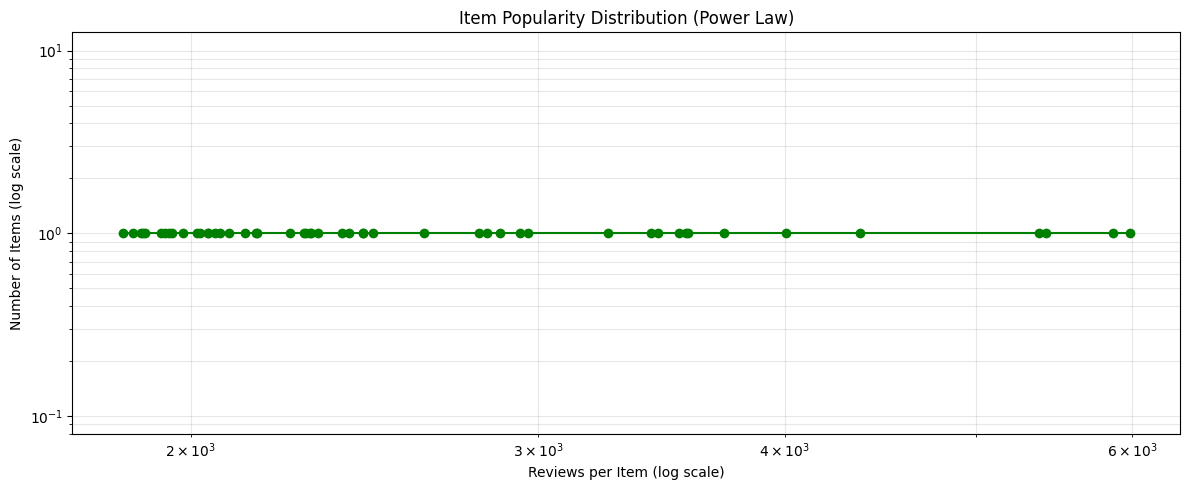

Top 20 most reviewed items:
               business_id  n_reviews  avg_star
0   _ab50qdWOk0DdB6XOrBitw       5982      4.61
1   ac1AeYqs8Z4_e2X5M3if2A       5865      4.68
2   GXFMD0Z4jEVZBCsbPf4CTQ       5425      4.71
3   ytynqOUb3hjKeJfRj5Tshw       5380      4.75
4   oBNrLz4EDhiscSlbOl8uAw       4369      4.70
5   _C7QiQQc47AOEv4PE3Kong       4008      4.77
6   GBTPC53ZrG1ZBY3DT8Mbcw       3726      4.63
7   I_3LMZ_1m2mzR0oLIOePIg       3575      4.75
8   6a4gLLFSgr-Q6CZXDLzBGQ       3567      4.66
9   gTC8IQ_i8zXytWSly3Ttvg       3538      4.72
10  yPSejq3_erxo9zdVYTBnZA       3450      4.78
11  VQcCL9PiNL_wkGf-uF3fjg       3424      4.61
12  1b5mnK8bMnnju_cvU65GqQ       3255      4.70
13  VaO-VW3e1kARkU9bP1E7Fw       2965      4.60
14  VVH6k9-ycttH3TV_lk5WfQ       2939      4.73
15  iSRTaT9WngzB8JJ2YKJUig       2870      4.49
16  ctHjyadbDQAtUFfkcAFEHw       2828      4.81
17  qb28j-FNX1_6xm7u372TZA       2799      4.59
18  QHWYlmVbLC3K6eglWoHVvA       2626      4.66
19  6ajnOk0G

In [ ]:
# Top 20 most reviewed businesses
top_items = con.execute(f"""
    WITH item_count AS (
        SELECT 
            business_id,
            COUNT(*) as n_reviews,
            AVG(stars) as avg_star
        FROM read_parquet('{review_flat}')
        WHERE stars >= 4.0
        GROUP BY business_id
    )
    SELECT 
        business_id,
        n_reviews,
        ROUND(avg_star, 2) as avg_star
    FROM item_count
    ORDER BY n_reviews DESC
    LIMIT 20
""").fetch_df()

# Popularity distribution
popularity = con.execute(f"""
    WITH item_count AS (
        SELECT 
            COUNT(*) as n_reviews
        FROM read_parquet('{review_flat}')
        WHERE stars >= 4.0
        GROUP BY business_id
    )
    SELECT 
        n_reviews,
        COUNT(*) as num_items
    FROM item_count
    GROUP BY n_reviews
    ORDER BY n_reviews ASC
""").fetch_df()

plt.figure(figsize=(12, 5))
plt.loglog(popularity['n_reviews'], popularity['num_items'], 'o-', color='green', markersize=6)
plt.xlabel('Reviews per Item (log scale)')
plt.ylabel('Number of Items (log scale)')
plt.title('Item Popularity Distribution (Power Law)')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("Top 20 most reviewed items:")
print(top_items)
print(f"\nTotal unique items with positive feedback: {len(popularity)}")

In [12]:
# User engagement metrics
user_stats = con.execute(f"""
    WITH user_activity AS (
        SELECT 
            user_id,
            COUNT(*) as n_reviews,
            AVG(stars) as avg_rating,
            MIN(date) as first_review,
            MAX(date) as last_review
        FROM read_parquet('{review_flat}')
        GROUP BY user_id
    )
    SELECT 
        ROUND(AVG(n_reviews), 2) as avg_reviews_per_user,
        ROUND(STDDEV(n_reviews), 2) as stddev_reviews,
        MIN(n_reviews) as min_reviews,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY n_reviews) as median_reviews,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY n_reviews) as p95_reviews,
        MAX(n_reviews) as max_reviews,
        COUNT(*) as total_users
    FROM user_activity
""").fetch_df()

print("User Engagement Summary:")
print(user_stats)

# Users by activity level
user_segments = con.execute(f"""
    WITH user_activity AS (
        SELECT COUNT(*) as n_reviews
        FROM read_parquet('{review_flat}')
        GROUP BY user_id
    )
    SELECT 
        'Power Users (100+ reviews)' as segment,
        COUNT(*) as count
    FROM user_activity
    WHERE n_reviews >= 100
    UNION ALL
    SELECT 
        'Active Users (10-99 reviews)',
        COUNT(*)
    FROM user_activity
    WHERE n_reviews BETWEEN 10 AND 99
    UNION ALL
    SELECT 
        'Casual Users (2-9 reviews)',
        COUNT(*)
    FROM user_activity
    WHERE n_reviews BETWEEN 2 AND 9
    UNION ALL
    SELECT 
        'One-time Users (1 review)',
        COUNT(*)
    FROM user_activity
    WHERE n_reviews = 1
""").fetch_df()

print("\nUser Segmentation:")
print(user_segments)

User Engagement Summary:
   avg_reviews_per_user  stddev_reviews  min_reviews  median_reviews  \
0                  3.52           12.77            1             1.0   

   p95_reviews  max_reviews  total_users  
0         11.0         3048      1987929  

User Segmentation:
                        segment    count
0    Power Users (100+ reviews)     4365
1  Active Users (10-99 reviews)   113005
2    Casual Users (2-9 reviews)   734551
3     One-time Users (1 review)  1136008


In [13]:
# Review text characteristics
review_chars = con.execute(f"""
    SELECT 
        COUNT(*) as total_reviews,
        COUNT(CASE WHEN text IS NOT NULL AND LENGTH(text) > 0 THEN 1 END) as reviews_with_text,
        ROUND(AVG(CASE WHEN text IS NOT NULL THEN LENGTH(text) ELSE 0 END), 0) as avg_text_length,
        ROUND(AVG(CASE WHEN text IS NOT NULL THEN LENGTH(text) / COALESCE(NULLIF(LENGTH(REGEXP_REPLACE(text, '[^ ]', '')), 0), 1) ELSE 0 END), 1) as avg_words_per_review
    FROM read_parquet('{review_flat}')
""").fetch_df()

print("Review Text Characteristics:")
print(review_chars)

# Useful column check
useful_stats = con.execute(f"""
    SELECT 
        COUNT(*) as total_reviews,
        SUM(useful) as total_useful_votes,
        ROUND(AVG(useful), 2) as avg_useful_votes
    FROM read_parquet('{review_flat}')
""").fetch_df()

print("\nReview Usefulness (if available):")
print(useful_stats)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Review Text Characteristics:
   total_reviews  reviews_with_text  avg_text_length  avg_words_per_review
0        6990280            6990280            568.0                   1.0

Review Usefulness (if available):
   total_reviews  total_useful_votes  avg_useful_votes
0        6990280           8280748.0              1.18


In [14]:
# Recommendation dataset potential
rec_potential = con.execute(f"""
    WITH pos_feedback AS (
        SELECT 
            COUNT(DISTINCT user_id) as active_users,
            COUNT(DISTINCT business_id) as active_items,
            COUNT(*) as interactions
        FROM read_parquet('{review_flat}')
        WHERE stars >= 4.0
    ),
    all_data AS (
        SELECT 
            COUNT(DISTINCT user_id) as all_users,
            COUNT(DISTINCT business_id) as all_items,
            COUNT(*) as all_interactions
        FROM read_parquet('{review_flat}')
    )
    SELECT 
        pf.active_users,
        pf.active_items,
        pf.interactions,
        ROUND((pf.interactions::FLOAT / (pf.active_users * pf.active_items)) * 100, 4) as sparsity_pct,
        ad.all_users,
        ad.all_items,
        ad.all_interactions
    FROM pos_feedback pf, all_data ad
""").fetch_df()

print("Recommendation Dataset Potential:")
print(rec_potential)

# Coverage metrics
coverage = con.execute(f"""
    WITH positive_reviews AS (
        SELECT 
            COUNT(DISTINCT user_id) as pos_users,
            COUNT(DISTINCT business_id) as pos_items
        FROM read_parquet('{review_flat}')
        WHERE stars >= 4.0
    ),
    all_reviews AS (
        SELECT 
            COUNT(DISTINCT user_id) as all_users,
            COUNT(DISTINCT business_id) as all_items
        FROM read_parquet('{review_flat}')
    )
    SELECT 
        ROUND(100.0 * pr.pos_users / ar.all_users, 2) as active_user_coverage_pct,
        ROUND(100.0 * pr.pos_items / ar.all_items, 2) as active_item_coverage_pct
    FROM positive_reviews pr, all_reviews ar
""").fetch_df()

print("\nCoverage Metrics:")
print(coverage)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Recommendation Dataset Potential:
   active_users  active_items  interactions  sparsity_pct  all_users  \
0       1464850        147491       4684545        0.0022    1987929   

   all_items  all_interactions  
0     150346           6990280  


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Coverage Metrics:
   active_user_coverage_pct  active_item_coverage_pct
0                     73.69                      98.1


In [15]:
print("=" * 60)
print("DATASET SUMMARY & KEY INSIGHTS")
print("=" * 60)

# Compile key metrics
summary_query = con.execute(f"""
    SELECT 
        COUNT(DISTINCT CASE WHEN stars >= 4.0 THEN user_id END) as target_users,
        COUNT(DISTINCT CASE WHEN stars >= 4.0 THEN business_id END) as target_items,
        COUNT(CASE WHEN stars >= 4.0 THEN 1 END) as target_interactions,
        COUNT(DISTINCT YEAR(date)) as year_span,
        ROUND(AVG(CASE WHEN stars >= 4.0 THEN stars END), 2) as avg_positive_rating
    FROM read_parquet('{review_flat}')
""").fetch_df()

row = summary_query.iloc[0]
print(f"\n📊 COLLABORATIVE FILTERING DATASET (stars ≥ 4.0):")
print(f"   • Users: {int(row['target_users']):,}")
print(f"   • Items: {int(row['target_items']):,}")
print(f"   • Interactions: {int(row['target_interactions']):,}")
print(f"   • Matrix density: {(int(row['target_interactions']) / (int(row['target_users']) * int(row['target_items']))) * 100:.4f}%")
print(f"   • Avg positive rating: {row['avg_positive_rating']} stars")
print(f"   • Time span: {int(row['year_span'])} years")

print(f"\n📈 DATASET CHARACTERISTICS:")
print(f"   • Highly sparse matrix (typical for recommendations)")
print(f"   • Power-law distributed user & item interactions")
print(f"   • Sufficient scale for learning latent representations")
print(f"   • Ready for ELSA pre-training + TopK SAE interpretation")

print(f"\n✅ RECOMMENDATION MODEL VIABILITY:")
print(f"   • Implicit feedback sufficient for collaborative filtering")
print(f"   • User-based and content-based hybrid possible")
print(f"   • Cold-start mitigation: substantial category/geographic data")
print("=" * 60)

DATASET SUMMARY & KEY INSIGHTS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


📊 COLLABORATIVE FILTERING DATASET (stars ≥ 4.0):
   • Users: 1,464,850
   • Items: 147,491
   • Interactions: 4,684,545
   • Matrix density: 0.0022%
   • Avg positive rating: 4.69 stars
   • Time span: 18 years

📈 DATASET CHARACTERISTICS:
   • Highly sparse matrix (typical for recommendations)
   • Power-law distributed user & item interactions
   • Sufficient scale for learning latent representations
   • Ready for ELSA pre-training + TopK SAE interpretation

✅ RECOMMENDATION MODEL VIABILITY:
   • Implicit feedback sufficient for collaborative filtering
   • User-based and content-based hybrid possible
   • Cold-start mitigation: substantial category/geographic data


## Category Distribution Analysis

CATEGORY DISTRIBUTION IN YELP DATASET

Loading businesses from: ..\..\..\Yelp-JSON\yelp_dataset\yelp_academic_dataset_business.json
Processing categories...


  Progress: 50000 lines...
  Progress: 100000 lines...
  Progress: 150000 lines...

✓ Loaded 150346 total businesses
✓ Found 150243 businesses with categories
✓ Total 1311 unique categories

TOP 30 CATEGORIES (by frequency)
 1. Restaurants                              █████████████████          52268 ( 34.8%)
 2. Food                                     █████████                  27781 ( 18.5%)
 3. Shopping                                 ████████                   24395 ( 16.2%)
 4. Home Services                            ████                       14356 (  9.6%)
 5. Beauty & Spas                            ████                       14292 (  9.5%)
 6. Nightlife                                ████                       12281 (  8.2%)
 7. Health & Medical                         ███                        11890 (  7.9%)
 8. Local Services                           ███                        11198 (  7.5%)
 9. Bars                                     ███                        11065 ( 

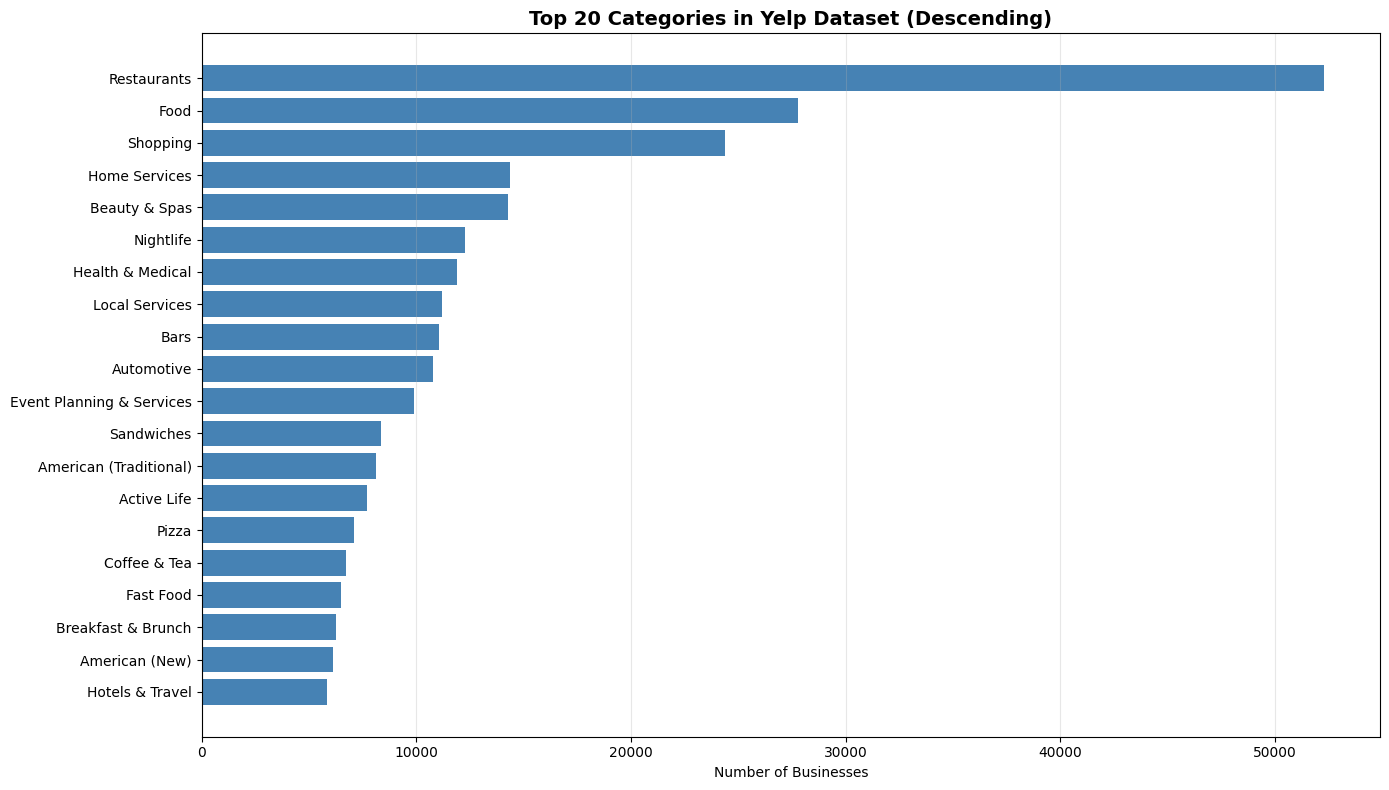

In [16]:
import json
from collections import Counter
import matplotlib.pyplot as plt

# Load business JSON and extract categories
print("=" * 80)
print("CATEGORY DISTRIBUTION IN YELP DATASET")
print("=" * 80)

json_path = Path("../../../Yelp-JSON/yelp_dataset/yelp_academic_dataset_business.json")

category_counter = Counter()
businesses_with_categories = 0
businesses_total = 0

print(f"\nLoading businesses from: {json_path}")
print("Processing categories...")

try:
    with open(json_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line_num, line in enumerate(f, 1):
            try:
                row = json.loads(line)
                businesses_total += 1
                
                categories_str = row.get('categories', '')
                if categories_str:
                    # Split comma-separated categories and clean
                    categories = [c.strip() for c in categories_str.split(',')]
                    category_counter.update(categories)
                    businesses_with_categories += 1
                
                if line_num % 50000 == 0:
                    print(f"  Progress: {line_num} lines...")
            except json.JSONDecodeError:
                pass
except Exception as e:
    print(f"Error: {e}")

print(f"\n✓ Loaded {businesses_total} total businesses")
print(f"✓ Found {businesses_with_categories} businesses with categories")
print(f"✓ Total {len(category_counter)} unique categories")

# Get top 30 categories
top_categories = category_counter.most_common(30)

print(f"\n" + "=" * 80)
print("TOP 30 CATEGORIES (by frequency)")
print("=" * 80)

for rank, (category, count) in enumerate(top_categories, 1):
    pct = (count / businesses_with_categories) * 100
    bar_len = int(pct / 2)
    bar = '█' * bar_len
    print(f"{rank:2d}. {category:<40s} {bar:25s} {count:6d} ({pct:5.1f}%)")

# Visualize top 20 categories
print(f"\n📊 Generating visualization...")

top_20 = category_counter.most_common(20)
cats_20 = [cat for cat, _ in top_20]
counts_20 = [count for _, count in top_20]

plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(cats_20)), counts_20, color='steelblue')
plt.yticks(range(len(cats_20)), cats_20)
plt.xlabel('Number of Businesses')
plt.title('Top 20 Categories in Yelp Dataset (Descending)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()